# Project VLAN4 Model ML Phising Detection via Chrome Plugin

## Problem Understanding

### Tujuan Projek
Membangun Model ML untuk mendeteksi SMISHING

## Data Collection & Lib Input

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

data = pd.read_csv('./dataset_sms_spam_v1-2.csv')
data2 = pd.read_csv('./dataset_sms_spam_v1.csv')

## EDA

### Data 1 (Manual Penambahan Data)

In [2]:
data.head()

,Teks,label
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,2
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,2
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",2
3,"2016-08-07 11:29:47.Plg Yth, sisa kuota Flash ...",2
4,4.5GB/30 hari hanya Rp 55 Ribu Spesial buat an...,2


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Teks    1315 non-null   object
 1   label   1315 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 20.7+ KB


In [4]:
#Cek Duplikat & Missing Value   
duplikat = data.duplicated().sum()
missing_value = data.isnull().sum()
print(f"Jumlah Duplikat: {duplikat}")
print(f"Jumlah Missing Value: \n{missing_value}")

Jumlah Duplikat: 47
Jumlah Missing Value: 
Teks     0
label    0
dtype: int64


In [5]:
data["label"].value_counts()


label
0    569
1    507
2    239
Name: count, dtype: int64

In [6]:
#Drop Duplikat
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [7]:
data["label"].value_counts()
#0 = Genuine
#1 = Phishing
#2 = Promotion

label
0    568
1    461
2    239
Name: count, dtype: int64

In [8]:
new_data = data[data["label"].isin([0, 1])] 
new_data.shape

(1029, 2)

In [9]:
new_data.head()

,Teks,label
239,"Jika anda bermasalah dgn CC/KT@, stres dgn bun...",1
240,"Lelah byr min payment? Kami Solusinya, bantu s...",1
241,"Dana Tunai (KTA) bunga 0,99% hingga 300 jt. Sy...",1
242,“ROXI CELL” Hanya dengan Rp.100rb Anda bisa ja...,1
243,3 RAMADHAN Selamat Anda Pemenang Rp.100jt. PIN...,1


In [10]:
print(f"persentase data genuine: {len(new_data[new_data['label'] == 0])/len(new_data)*100:.2f}%")
print(f"persentase data phising: {len(new_data[new_data['label'] == 1])/len(new_data)*100:.2f}%")

persentase data genuine: 55.20%
persentase data phising: 44.80%


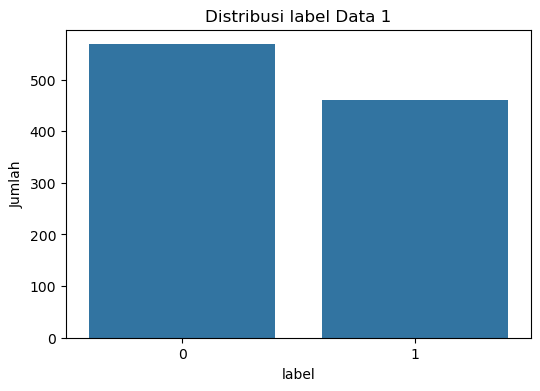

In [11]:
#Grafik pyplot data genuine vs phising
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=new_data)
plt.title('Distribusi label Data 1')
plt.xlabel('label')
plt.ylabel('Jumlah')
plt.show()

### Data 2 (Menggunakan Smote untuk data balancing)

In [12]:
data2.head()

,Teks,label
0,[PROMO] Beli paket Flash mulai 1GB di MY TELKO...,2
1,2.5 GB/30 hari hanya Rp 35 Ribu Spesial buat A...,2
2,"2016-07-08 11:47:11.Plg Yth, sisa kuota Flash ...",2
3,"2016-08-07 11:29:47.Plg Yth, sisa kuota Flash ...",2
4,4.5GB/30 hari hanya Rp 55 Ribu Spesial buat an...,2


In [13]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Teks    1143 non-null   object
 1   label   1143 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 18.0+ KB


In [14]:
#Cek Duplikat & Missing Value
duplikat = data2.duplicated().sum()
missing_value = data2.isnull().sum()
print(f"Jumlah Duplikat: {duplikat}")
print(f"Jumlah Missing Value: {missing_value}")

Jumlah Duplikat: 1
Jumlah Missing Value: Teks     0
label    0
dtype: int64


In [15]:
data2["label"].value_counts()
#0 = Genuine
#1 = Phishing
#2 = Promotion

label
0    569
1    335
2    239
Name: count, dtype: int64

In [16]:
new_data2 = data2[data2["label"].isin([0, 1])] 
new_data2.shape

(904, 2)

In [17]:
new_data2.head()

,Teks,label
239,"Jika anda bermasalah dgn CC/KT@, stres dgn bun...",1
240,"Lelah byr min payment? Kami Solusinya, bantu s...",1
241,"Dana Tunai (KTA) bunga 0,99% hingga 300 jt. Sy...",1
242,“ROXI CELL” Hanya dengan Rp.100rb Anda bisa ja...,1
243,3 RAMADHAN Selamat Anda Pemenang Rp.100jt. PIN...,1


In [18]:
print(f"persentase data genuine: {len(new_data2[new_data2['label'] == 0])/len(new_data2)*100:.2f}%")
print(f"persentase data phising: {len(new_data2[new_data2['label'] == 1])/len(new_data2)*100:.2f}%")

persentase data genuine: 62.94%
persentase data phising: 37.06%


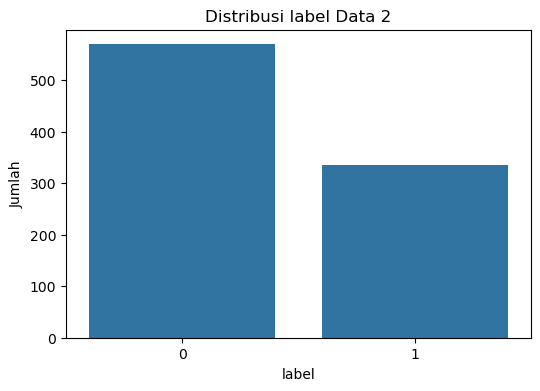

In [19]:
#Grafik pyplot data genuine vs phising
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=new_data2)
plt.title('Distribusi label Data 2')
plt.xlabel('label')
plt.ylabel('Jumlah')
plt.show()

In [20]:
text = new_data['Teks'].iloc[1]
print(text)

Lelah byr min payment? Kami Solusinya, bantu secara LEGAL penutupan CC/KTA, dscn 50-75%. Hub.LoLyta 081316523061/087822962308 (WA). LEGAL


In [21]:
#lowercase
text = text.lower()
print(text)

lelah byr min payment? kami solusinya, bantu secara legal penutupan cc/kta, dscn 50-75%. hub.lolyta 081316523061/087822962308 (wa). legal


In [22]:
#Remove Noise
text = re.sub(r'http\S+|@\w+|#[A-Za-z0-9_]+|www\.\S+', ' ', text)
text = re.sub(r'[^a-zA-Z\s]', ' ', text)                  
text = re.sub(r'\s+', ' ', text).strip() 
print(text)

lelah byr min payment kami solusinya bantu secara legal penutupan cc kta dscn hub lolyta wa legal


In [23]:
#Tokenize
tokens = word_tokenize(text)
print(tokens)

['lelah', 'byr', 'min', 'payment', 'kami', 'solusinya', 'bantu', 'secara', 'legal', 'penutupan', 'cc', 'kta', 'dscn', 'hub', 'lolyta', 'wa', 'legal']


In [24]:
# Stopword Removal
stop_words = set(stopwords.words('indonesian'))
tokens = [w for w in tokens if w not in stop_words]
text = " ".join(tokens)

In [25]:
# Stemming Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()
Token_Stemmer = [stemmer.stem(w) for w in tokens]
print(Token_Stemmer)    

['lelah', 'byr', 'min', 'payment', 'solusi', 'bantu', 'legal', 'tutup', 'cc', 'kta', 'dscn', 'hub', 'lolyta', 'wa', 'legal']


In [26]:
def Preoprocessing(text):
    #1. Lowercase
    text = text.lower()
    #2. Remove Noise
    text = re.sub(r'http\S+|@\w+|#[A-Za-z0-9_]+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)                  
    text = re.sub(r'\s+', ' ', text).strip() 
    #3. Tokenize
    tokens = word_tokenize(text)
    #4. Stopword Removal
    tokens = [w for w in tokens if w not in stop_words]
    #5. Stemming Sastrawi
    text = " ".join(tokens)
    text = stemmer.stem(text)
    return text


In [27]:
# Apply Preprocessing ke data 1
data_clean = new_data.Teks.apply(Preoprocessing)
data_clean.head()

239    masalah dgn cc kt stres dgn bunga lunas disc s...
240    lelah byr min payment solusi bantu legal tutup...
241    dana tunai kta bunga jt syarat ktp cc dgn bpkb...
242    roxi cell rp rb agen pulsa elektrik operator g...
243    ramadhan selamat menang rp jt pin code y r k z...
Name: Teks, dtype: object

In [28]:
# Apply Preprocessing ke data 2
data_clean2 = new_data2.Teks.apply(Preoprocessing)
data_clean2.head()

239    masalah dgn cc kt stres dgn bunga lunas disc s...
240    lelah byr min payment solusi bantu legal tutup...
241    dana tunai kta bunga jt syarat ktp cc dgn bpkb...
242    roxi cell rp rb agen pulsa elektrik operator g...
243    ramadhan selamat menang rp jt pin code y r k z...
Name: Teks, dtype: object

In [29]:
data_clean = data_clean.to_frame()
data_clean2 = data_clean2.to_frame()

In [30]:
data_clean['label'] = new_data['label']
data_clean.head()

data_clean2['label'] = new_data2['label']
data_clean2.head()

,Teks,label
239,masalah dgn cc kt stres dgn bunga lunas disc s...,1
240,lelah byr min payment solusi bantu legal tutup...,1
241,dana tunai kta bunga jt syarat ktp cc dgn bpkb...,1
242,roxi cell rp rb agen pulsa elektrik operator g...,1
243,ramadhan selamat menang rp jt pin code y r k z...,1


In [31]:
#ubah kata jadi angka
tfidf1 = TfidfVectorizer()
tfidf_data = tfidf1.fit_transform(data_clean['Teks'])

tfidf2 = TfidfVectorizer()
tfidf_data2 = tfidf2.fit_transform(data_clean2['Teks'])

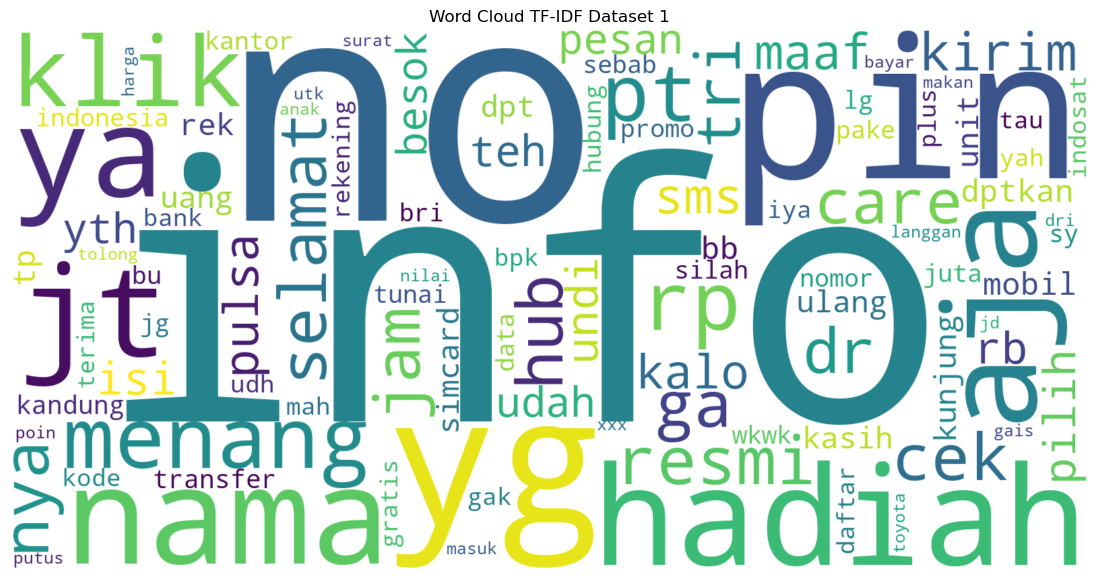

In [55]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

# Mengambil rata-rata bobot TF-IDF setiap kata
tfidf_scores = np.asarray(tfidf_data.mean(axis=0)).flatten()

# Nama kata
feature_names = tfidf1.get_feature_names_out()

# Membuat dictionary kata:bobot
word_freq = dict(zip(feature_names, tfidf_scores))

# Word Cloud
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    max_words=100
).generate_from_frequencies(word_freq)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud TF-IDF Dataset 1')
plt.show()

## Data Preparation

In [32]:
X = tfidf_data
y = data_clean['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X2 = tfidf_data2
y2 = data_clean2['label']
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [33]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(823, 3109)
(206, 3109)
(823,)
(206,)


### SMOTE Data 2 Biar Balance

In [34]:
from imblearn.over_sampling import SMOTE
from collections import Counter


# Sebelum SMOTE
print("Sebelum SMOTE:")
print(Counter(y_train2))

# SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train2,
    y_train2
)

# Sesudah SMOTE
print("\nSesudah SMOTE:")
print(Counter(y_train_smote))

Sebelum SMOTE:
Counter({0: 461, 1: 262})

Sesudah SMOTE:
Counter({1: 461, 0: 461})


## Model Selection 

### Model yang kami pilih untuk digunakan adalah:
#### 1. Naive Bayes dengan parameter (alpha)
#### 2. Random Forest dengan parameter (n_estimators, random_state, n_jobs)
#### 3. Logistic Regression dengan parameter (max_iter, random_state,solver)
#### 4. SVM dengan parameter (kernel, random_state)
#### 5. XGBoost dengan parameter (n_estimators, random_state, n_jobs)
#### 6. KNN dengan parameter (n_neighbors, n_jobs)
#### 7. LightGBM dengan parameter (n_estimators, random_state, n_jobs)

## Model Training Data 1

Naive Bayes
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       111
           1       0.94      0.94      0.94        95

    accuracy                           0.94       206
   macro avg       0.94      0.94      0.94       206
weighted avg       0.94      0.94      0.94       206

Accuracy: 0.941747572815534


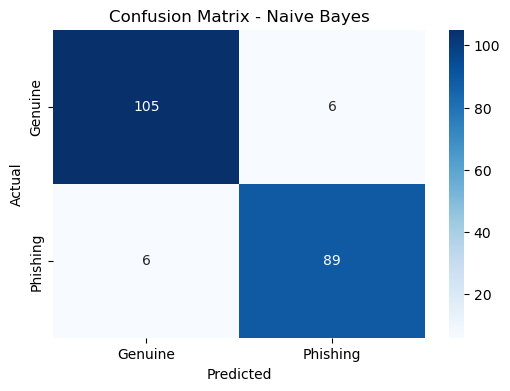

In [35]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB
MultiNB = MultinomialNB(alpha=0.1).fit(X_train, y_train)
MultiNB_Pred = MultiNB.predict(X_test)
print("Naive Bayes")
print(classification_report(y_test, MultiNB_Pred))
print("Accuracy:", accuracy_score(y_test, MultiNB_Pred))


cm = confusion_matrix(y_test, MultiNB_Pred)
cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

Random Forest
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       111
           1       0.99      0.83      0.90        95

    accuracy                           0.92       206
   macro avg       0.93      0.91      0.92       206
weighted avg       0.93      0.92      0.92       206

Accuracy: 0.9174757281553398


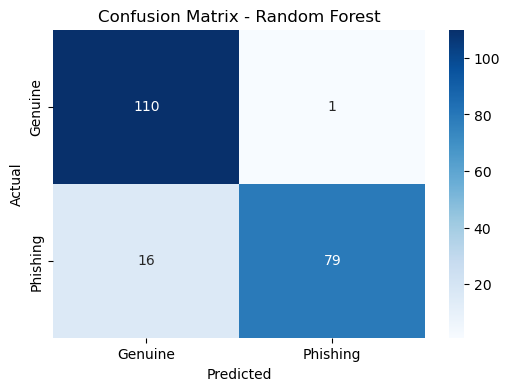

In [36]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
).fit(X_train, y_train)

RF_Pred = RF.predict(X_test)

print("Random Forest")
print(classification_report(y_test, RF_Pred))
print("Accuracy:", accuracy_score(y_test, RF_Pred))

cm = confusion_matrix(y_test, RF_Pred)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       111
           1       0.97      0.77      0.86        95

    accuracy                           0.88       206
   macro avg       0.90      0.88      0.88       206
weighted avg       0.90      0.88      0.88       206

Accuracy: 0.883495145631068


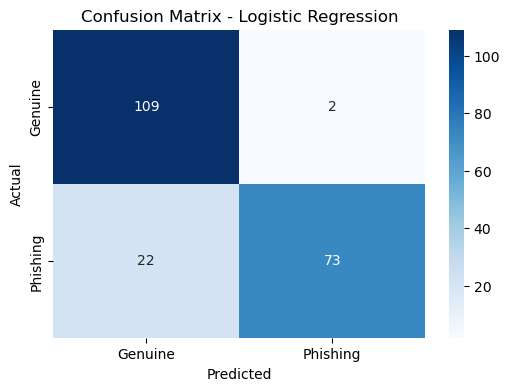

In [37]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs').fit(X_train, y_train)
LR_Pred = LR.predict(X_test)
print("Logistic Regression")
print(classification_report(y_test, LR_Pred))
print("Accuracy:", accuracy_score(y_test, LR_Pred))

cm = confusion_matrix(y_test, LR_Pred)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

SVM
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       111
           1       0.96      0.85      0.91        95

    accuracy                           0.92       206
   macro avg       0.92      0.91      0.92       206
weighted avg       0.92      0.92      0.92       206

Accuracy: 0.9174757281553398


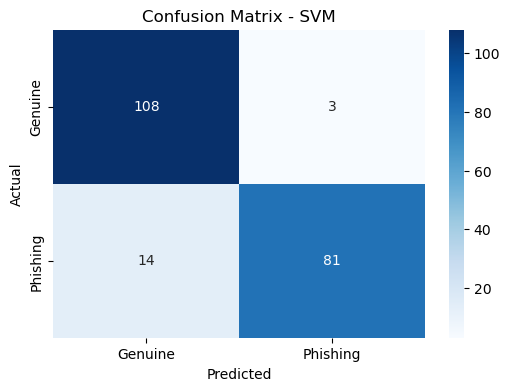

In [38]:
#SVM
from sklearn.svm import SVC
SVM = SVC(kernel='linear', random_state=42, C=0.5 , gamma='scale').fit(X_train, y_train)
SVM_Pred = SVM.predict(X_test)
print("SVM")
print(classification_report(y_test, SVM_Pred))
print("Accuracy:", accuracy_score(y_test, SVM_Pred))

cm = confusion_matrix(y_test, SVM_Pred)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

XGBoost
              precision    recall  f1-score   support

           0       0.85      0.96      0.90       111
           1       0.95      0.80      0.87        95

    accuracy                           0.89       206
   macro avg       0.90      0.88      0.89       206
weighted avg       0.90      0.89      0.89       206

Accuracy: 0.8883495145631068


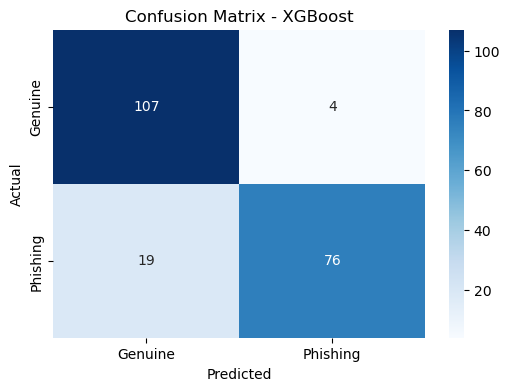

In [39]:
#XGBoost
from xgboost import XGBClassifier
XGB = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
XGB_Pred = XGB.predict(X_test)
print("XGBoost")
print(classification_report(y_test, XGB_Pred))
print("Accuracy:", accuracy_score(y_test, XGB_Pred))

cm = confusion_matrix(y_test, XGB_Pred)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

KNN
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       111
           1       0.88      0.92      0.90        95

    accuracy                           0.90       206
   macro avg       0.90      0.90      0.90       206
weighted avg       0.90      0.90      0.90       206

Accuracy: 0.9029126213592233


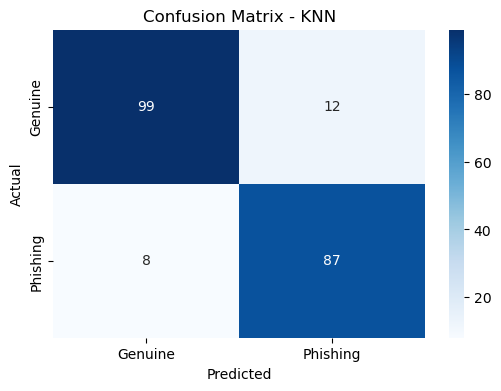

In [40]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(n_neighbors=3, n_jobs=-1).fit(X_train, y_train)
KNN_Pred = KNN.predict(X_test)
print("KNN")
print(classification_report(y_test, KNN_Pred))
print("Accuracy:", accuracy_score(y_test, KNN_Pred))
cm = confusion_matrix(y_test, KNN_Pred)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - KNN')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [41]:
#lightgbm
from lightgbm import LGBMClassifier
LGBM = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
LGBM_Pred = LGBM.predict(X_test)

[LightGBM] [Info] Number of positive: 366, number of negative: 457
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 900
[LightGBM] [Info] Number of data points in the train set: 823, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444714 -> initscore=-0.222050
[LightGBM] [Info] Start training from score -0.222050
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

d:\Anaconda\envs\env1\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM
              precision    recall  f1-score   support

           0       0.79      0.96      0.87       111
           1       0.94      0.71      0.81        95

    accuracy                           0.84       206
   macro avg       0.87      0.83      0.84       206
weighted avg       0.86      0.84      0.84       206

Accuracy: 0.8446601941747572


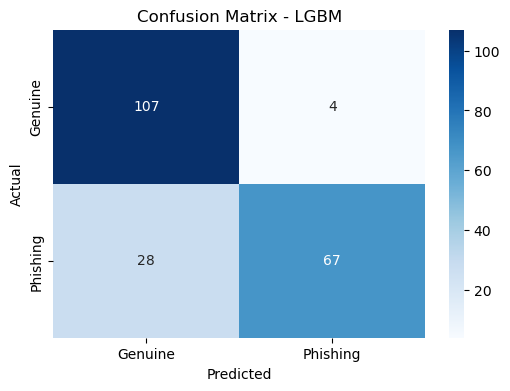

In [42]:
print("LightGBM")
print(classification_report(y_test, LGBM_Pred))
print("Accuracy:", accuracy_score(y_test, LGBM_Pred))

cm = confusion_matrix(y_test, LGBM_Pred)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - LGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

## Graf Perbandingan Data 1

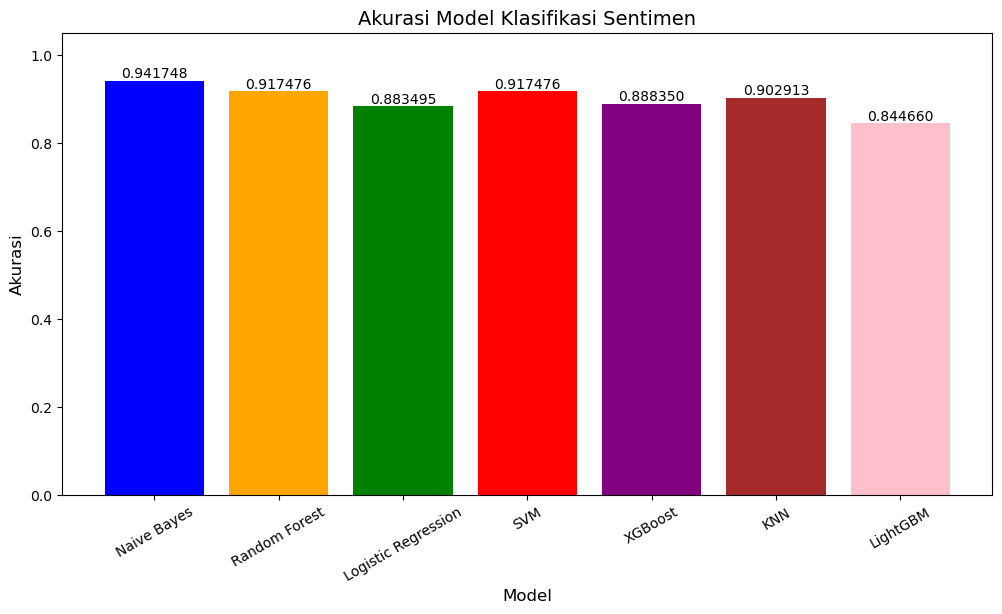

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ['Naive Bayes', 'Random Forest', 'Logistic Regression',
          'SVM', 'XGBoost', 'KNN', 'LightGBM']

accuracy = [
    accuracy_score(y_test, MultiNB_Pred),
    accuracy_score(y_test, RF_Pred),
    accuracy_score(y_test, LR_Pred),
    accuracy_score(y_test, SVM_Pred),
    accuracy_score(y_test, XGB_Pred),
    accuracy_score(y_test, KNN_Pred),
    accuracy_score(y_test, LGBM_Pred)
]

plt.figure(figsize=(12,6))

bars = plt.bar(
    models,
    accuracy,
    color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
)

plt.title('Akurasi Model Klasifikasi Sentimen', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)

for bar, acc in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{acc:.6f}', 
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=30)

# biar range y lebih pas
plt.ylim(0, 1.05)

plt.show()

## Model Training Data 2

Naive Bayes with smote
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       108
           1       0.99      0.96      0.97        73

    accuracy                           0.98       181
   macro avg       0.98      0.97      0.98       181
weighted avg       0.98      0.98      0.98       181

Accuracy: 0.9779005524861878


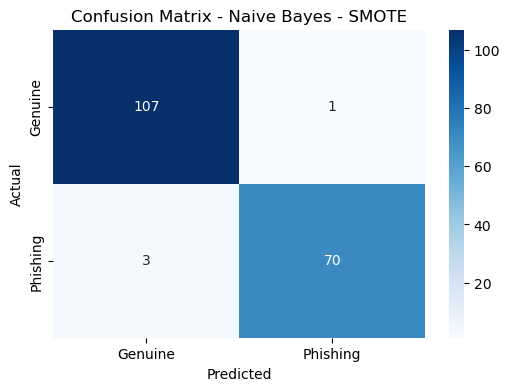

In [44]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB
MultiNB2 = MultinomialNB(alpha=1.0).fit(X_train_smote, y_train_smote)
MultiNB_Pred2 = MultiNB2.predict(X_test2)
print("Naive Bayes with smote")
print(classification_report(y_test2, MultiNB_Pred2))
print("Accuracy:", accuracy_score(y_test2, MultiNB_Pred2))


cm = confusion_matrix(y_test2, MultiNB_Pred2)
cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - Naive Bayes - SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

Random Forest with smote
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       108
           1       1.00      0.88      0.93        73

    accuracy                           0.95       181
   macro avg       0.96      0.94      0.95       181
weighted avg       0.95      0.95      0.95       181

Accuracy: 0.9502762430939227


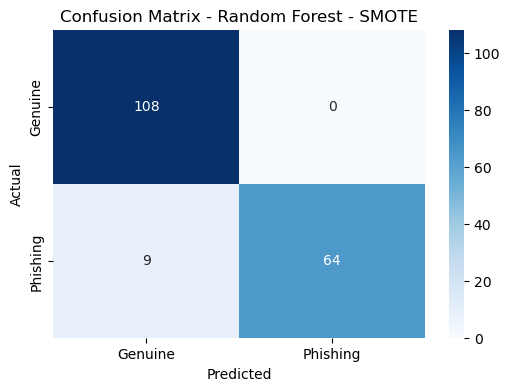

In [45]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

RF2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
).fit(X_train_smote, y_train_smote)

RF_Pred2 = RF2.predict(X_test2)

print("Random Forest with smote")
print(classification_report(y_test2, RF_Pred2))
print("Accuracy:", accuracy_score(y_test2, RF_Pred2))

cm = confusion_matrix(y_test2, RF_Pred2)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - Random Forest - SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

Logistic Regression with smote
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       108
           1       1.00      0.82      0.90        73

    accuracy                           0.93       181
   macro avg       0.95      0.91      0.92       181
weighted avg       0.94      0.93      0.93       181

Accuracy: 0.9281767955801105


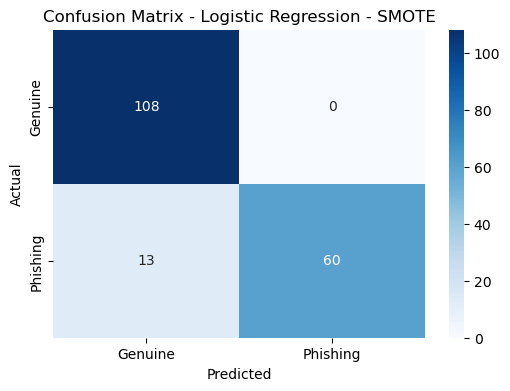

In [46]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
LR2 = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs').fit(X_train_smote, y_train_smote)
LR_Pred2 = LR2.predict(X_test2)
print("Logistic Regression with smote")
print(classification_report(y_test2, LR_Pred2))
print("Accuracy:", accuracy_score(y_test2, LR_Pred2))

cm = confusion_matrix(y_test2, LR_Pred2)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - Logistic Regression - SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

SVM with smote
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       108
           1       1.00      0.88      0.93        73

    accuracy                           0.95       181
   macro avg       0.96      0.94      0.95       181
weighted avg       0.95      0.95      0.95       181

Accuracy: 0.9502762430939227


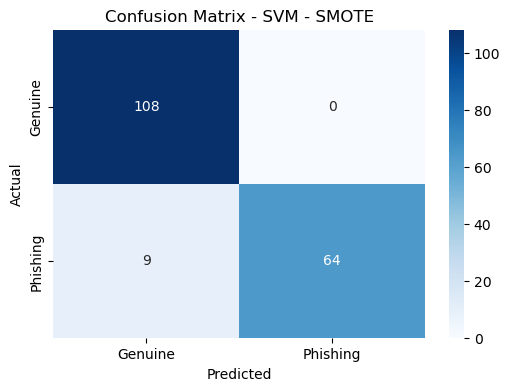

In [47]:
#SVM
from sklearn.svm import SVC
SVM2 = SVC(kernel='linear', random_state=42).fit(X_train_smote, y_train_smote)
SVM_Pred2 = SVM2.predict(X_test2)
print("SVM with smote")
print(classification_report(y_test2, SVM_Pred2))
print("Accuracy:", accuracy_score(y_test2, SVM_Pred2))

cm = confusion_matrix(y_test2, SVM_Pred2)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - SVM - SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

XGBoost with smote
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       108
           1       1.00      0.86      0.93        73

    accuracy                           0.94       181
   macro avg       0.96      0.93      0.94       181
weighted avg       0.95      0.94      0.94       181

Accuracy: 0.9447513812154696


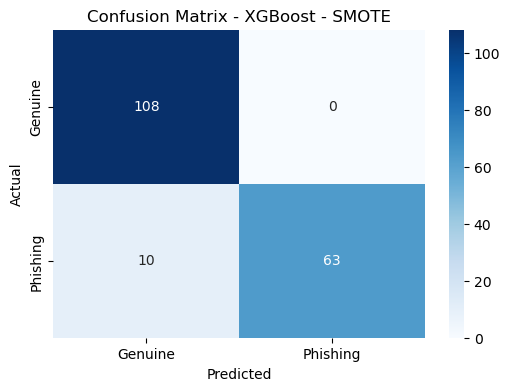

In [48]:
#XGBoost
from xgboost import XGBClassifier
XGB2 = XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train_smote, y_train_smote)
XGB_Pred2 = XGB2.predict(X_test2)
print("XGBoost with smote")
print(classification_report(y_test2, XGB_Pred2))
print("Accuracy:", accuracy_score(y_test2, XGB_Pred2))

cm = confusion_matrix(y_test2, XGB_Pred2)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - XGBoost - SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

KNN with smote
              precision    recall  f1-score   support

           0       0.97      0.56      0.71       108
           1       0.60      0.97      0.74        73

    accuracy                           0.72       181
   macro avg       0.78      0.76      0.72       181
weighted avg       0.82      0.72      0.72       181

Accuracy: 0.7237569060773481


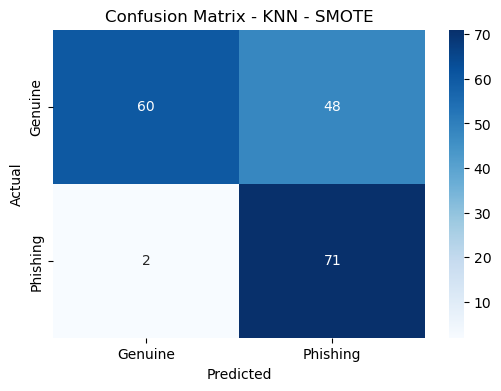

In [49]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
KNN2 = KNeighborsClassifier(n_neighbors=2, n_jobs=-1).fit(X_train_smote, y_train_smote)
KNN_Pred2 = KNN2.predict(X_test2)
print("KNN with smote")
print(classification_report(y_test2, KNN_Pred2))
print("Accuracy:", accuracy_score(y_test2, KNN_Pred2))
cm = confusion_matrix(y_test2, KNN_Pred2)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - KNN - SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [50]:
#lightgbm
from lightgbm import LGBMClassifier
LGBM2 = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train_smote, y_train_smote)
LGBM_Pred2 = LGBM2.predict(X_test2)

[LightGBM] [Info] Number of positive: 461, number of negative: 461
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2115
[LightGBM] [Info] Number of data points in the train set: 922, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

d:\Anaconda\envs\env1\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM with smote
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       108
           1       1.00      0.89      0.94        73

    accuracy                           0.96       181
   macro avg       0.97      0.95      0.95       181
weighted avg       0.96      0.96      0.96       181

Accuracy: 0.9558011049723757


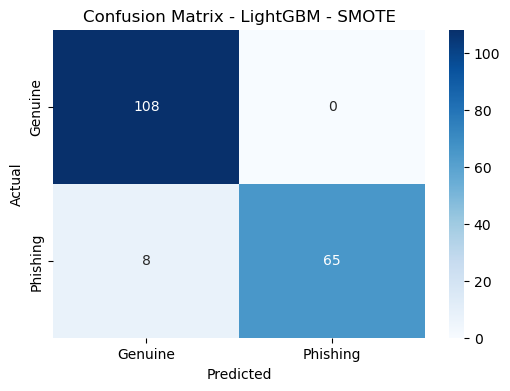

In [51]:
print("LightGBM with smote")
print(classification_report(y_test2, LGBM_Pred2))
print("Accuracy:", accuracy_score(y_test2, LGBM_Pred2))

cm = confusion_matrix(y_test2, LGBM_Pred2)

cm_df = pd.DataFrame(
    cm,
    index=['Genuine', 'Phishing'],
    columns=['Genuine', 'Phishing']
)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, cmap='Blues', fmt='d')

plt.title('Confusion Matrix - LightGBM - SMOTE')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

## Graf Perbandingan Data 2 (SMOTE)

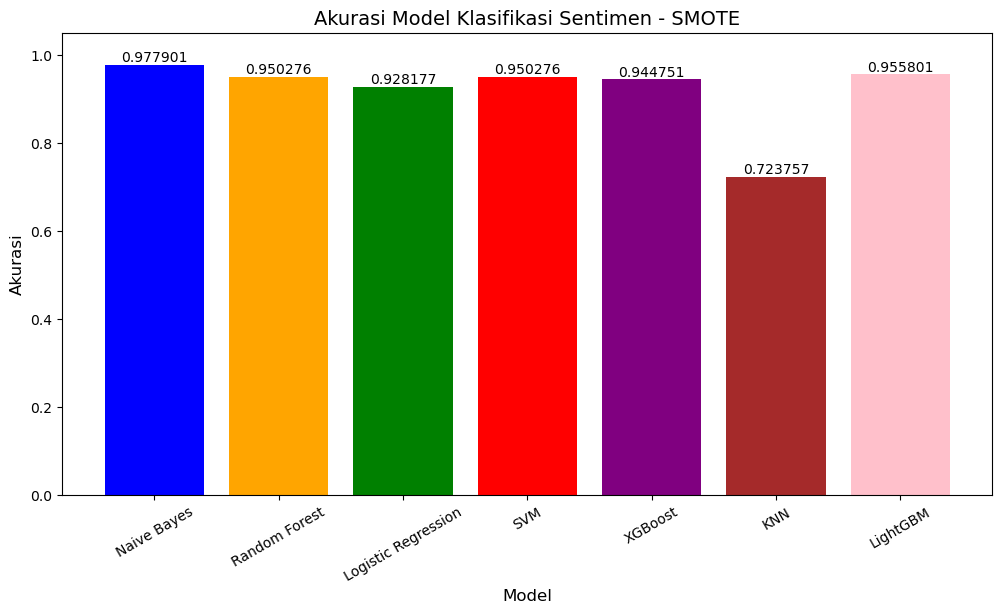

In [52]:
models = ['Naive Bayes', 'Random Forest', 'Logistic Regression',
          'SVM', 'XGBoost', 'KNN', 'LightGBM']

accuracy = [
    accuracy_score(y_test2, MultiNB_Pred2),
    accuracy_score(y_test2, RF_Pred2),
    accuracy_score(y_test2, LR_Pred2),
    accuracy_score(y_test2, SVM_Pred2),
    accuracy_score(y_test2, XGB_Pred2),
    accuracy_score(y_test2, KNN_Pred2),
    accuracy_score(y_test2, LGBM_Pred2)
]

plt.figure(figsize=(12,6))

bars = plt.bar(
    models,
    accuracy,
    color=['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
)

plt.title('Akurasi Model Klasifikasi Sentimen - SMOTE', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)

for bar, acc in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{acc:.6f}', 
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=30)

# biar range y lebih pas
plt.ylim(0, 1.05)

plt.show()

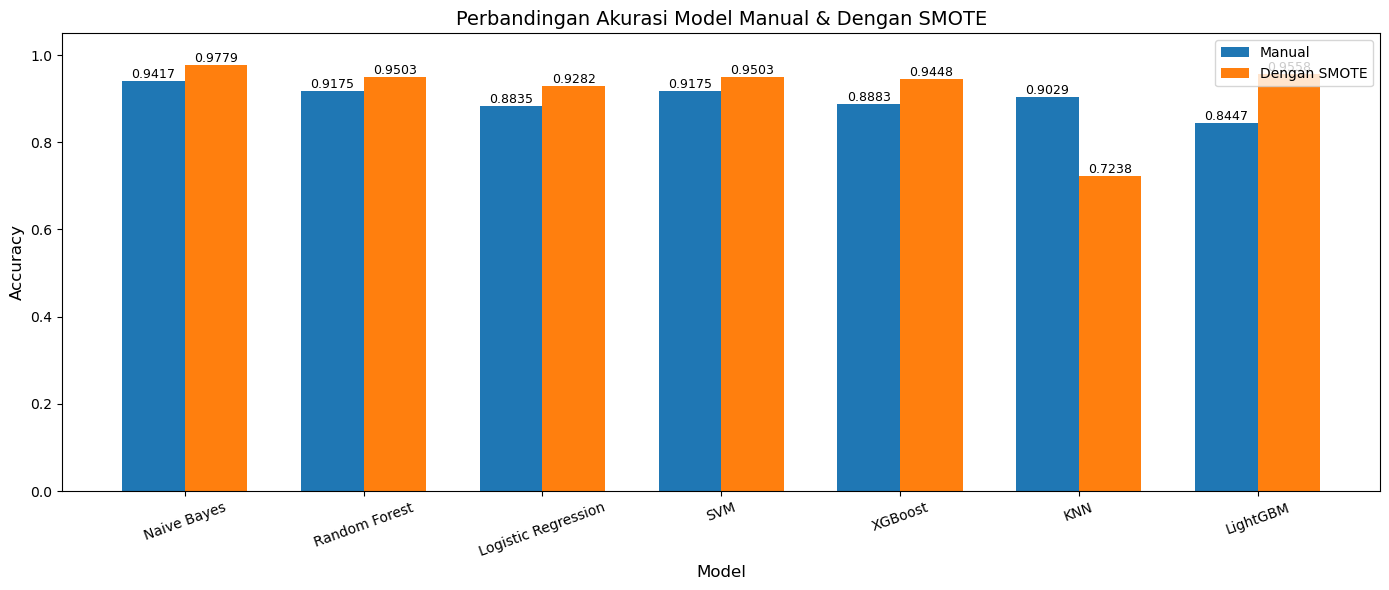

In [53]:
# Nama model
models = [
    'Naive Bayes',
    'Random Forest',
    'Logistic Regression',
    'SVM',
    'XGBoost',
    'KNN',
    'LightGBM'
]

# Accuracy tanpa SMOTE
accuracy_before = [
    accuracy_score(y_test, MultiNB_Pred),
    accuracy_score(y_test, RF_Pred),
    accuracy_score(y_test, LR_Pred),
    accuracy_score(y_test, SVM_Pred),
    accuracy_score(y_test, XGB_Pred),
    accuracy_score(y_test, KNN_Pred),
    accuracy_score(y_test, LGBM_Pred)
]

# Accuracy dengan SMOTE
accuracy_after = [
    accuracy_score(y_test2, MultiNB_Pred2),
    accuracy_score(y_test2, RF_Pred2),
    accuracy_score(y_test2, LR_Pred2),
    accuracy_score(y_test2, SVM_Pred2),
    accuracy_score(y_test2, XGB_Pred2),
    accuracy_score(y_test2, KNN_Pred2),
    accuracy_score(y_test2, LGBM_Pred2)
]

# Posisi bar
x = np.arange(len(models))
width = 0.35

# Figure
plt.figure(figsize=(14,6))

# Bar chart
bars1 = plt.bar(
    x - width/2,
    accuracy_before,
    width,
    label='Manual'
)

bars2 = plt.bar(
    x + width/2,
    accuracy_after,
    width,
    label='Dengan SMOTE'
)

# Judul dan label
plt.title('Perbandingan Akurasi Model Manual & Dengan SMOTE', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

# Nama model di sumbu x
plt.xticks(x, models, rotation=20)

# Range y
plt.ylim(0, 1.05)

# Legend
plt.legend()

# Tambahkan nilai accuracy di atas bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{yval:.4f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

for bar in bars2:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{yval:.4f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [54]:
import joblib

joblib.dump(MultiNB, 'model_multinomial_nb.pkl')

joblib.dump(tfidf1, 'tfidf.pkl')

print("Model dan TF-IDF berhasil disimpan!")

Model dan TF-IDF berhasil disimpan!
